![Sonar Mine Detection](images/00_sonar_mine_detection_cover.png)

# Sonar Mine Detection — Exploratory Data Analysis
---

### Problem Context:

Submarines must distinguish underwater mines from natural rock formations using sonar echoes. A missed mine means loss of vessel, crew, and mission. False alarms waste resources but remain survivable.

The detection system must therefore reflect this imbalance rather than optimise for **raw accuracy** alone.


### Objectives:

**Business:** Enable safe submarine operations by reliably detecting mines before they threaten the vessel.

**ML Performance Targets:**
- **Recall ≈ 100%** — Every mine detected (operational target: ≥98% on test set)
- **Precision ≥ 70%** — False positives controlled (≤30% false positive rate)

**What good looks like:** zero missed mines on the test set with precision high enough to remain operationally credible.

**Deployment:** Champion model operationalized through FastAPI service, containerized with Docker. Accepts 60-band sonar arrays, returns classifications with confidence scores for real-time integration.

---

### Analysis Roadmap:

1. **Data Loading and Preparation** — dataset ingestion, stratified train/test split, leakage prevention
2. **Data Quality & Class Distribution** — completeness checks, balance assessment, cost-asymmetry handling
3. **Feature Correlation Patterns** — multicollinearity (VIF), class signatures, non-linearity (MI), PCA
4. **Class Separability** — KDE distribution analysis across frequency spectrum
5. **Preprocessing Requirements** — scaling needs, outlier treatment, feature characteristics
6. **Modeling Strategy** — evidence-based algorithm recommendations


In [6]:
# The standard imports
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Import EDA workflow written seperately to hold main eda logic and keep notebook light
from ml_toolkit.eda import EDAWorkflow, load_dataset
from configs.config import DATA_RAW_PATH, OUTCOME_MAPPING, TEST_SIZE, DEFAULT_SEED

# Configuration for EDA calcs and presentation format
CONFIG = {
    'target_col': 'outcome',
    'test_size': TEST_SIZE,
    'random_seed': DEFAULT_SEED,
    'class_labels': {0: 'Rock', 1: 'Mine'},
    'colors': {
        'class_0': '#426590',  
        'class_1': '#AF80B0'   
    }
}

print(f"Environment configured, Random seed: {CONFIG['random_seed']}, Test size: {CONFIG['test_size']*100:.0f}%")

Environment configured, Random seed: 1206, Test size: 20%


### 1 Data Loading and preparation

The loading function assigns sequential identifiers (`feature_0` through `feature_59`) and maps the categorical outcome labels (R for rock, M for mine) to binary integers (0 and 1 respectively). This standardisation enables consistent processing while preserving the original signal structure.

In [ ]:
# Load complete dataset
df, schema = load_dataset(path=DATA_RAW_PATH, outcome_mapping=OUTCOME_MAPPING)
display(df.head(3))

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,outcome
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,0
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,0
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,0


### 1.1 Train/Test Split — Preventing Data Leakage

We perform a stratified 80/20 split, giving us 166 training samples and 42 test samples. 

**Why This Matters:** Every subsequent analysis uses only the *training set*. The *test set* remains untouched, serving as our proxy for real-world deployment. When we finally evaluate the champion model against these 42 samples, we get an honest estimate of field performance, uncorrupted by analytical choices that might have been influenced by test set patterns.

In [25]:
# Test / Train Stratified split to avoid surprises on outcome proportion

X = df.drop('outcome', axis=1)
y = df['outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_seed'],
    stratify=y
)

# Recombine for EDA
df_train = X_train.copy()
df_train['outcome'] = y_train

df_test = X_test.copy()
df_test['outcome'] = y_test


print(f"Training set: {len(df_train)} samples ({(1-CONFIG['test_size'])*100:.0f}%)")
print(f"Test set: {len(df_test)} samples ({CONFIG['test_size']*100:.0f}%)")



Training set: 166 samples (80%)
Test set: 42 samples (20%)


---

## 2.0 Data Quality & Class Distribution

**Key insight:**

The training data is clean: zero missing values, zero duplicates, zero sparse features. All 60 frequency bands register measurements with meaningful variation. No imputation or feature removal needed.

Class balance is near-perfect: 88 rocks (53%) versus 78 mines (47%). No resampling required.

Given the asymmetric costs established earlier, we train models using F2 score (emphasizes recall) and reserve threshold tuning for post-training deployment optimisation.

**DECISION:** We use training dataset as is. Train on F2 score. Handle cost asymmetry through threshold tuning, not class weights.

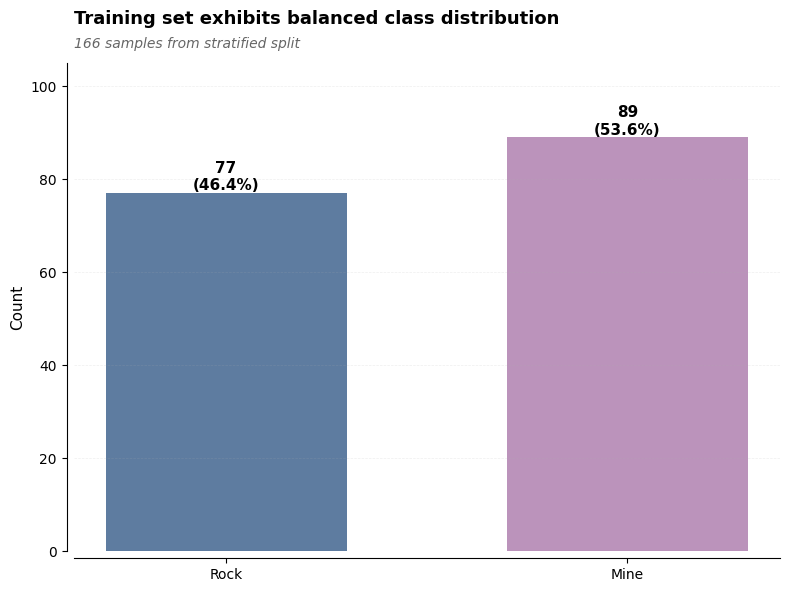

In [24]:
# Initialize workflow with training data
eda = EDAWorkflow(df_train, CONFIG)

# Run quality assessment
quality = eda.assess_quality()
#quality.summarize()

# Run distribution analysis
#distribution = eda.analyze_class_distribution()
#distribution.summarize()
# Run class distribution analysis
distribution = eda.analyze_class_distribution()

# Display class split Mine vs Rock
distribution.plot()

# Display findings extra telemetry
#distribution.summarize()

---

## 3. Feature Correlation Patterns

Four analyses examine how frequency bands relate to each other and to the classification target. Each tests a specific hypothesis about the feature structure, informing model selection and preprocessing decisions.

In [28]:
# Run all correlation analyses
correlations = eda.analyze_correlations()
#correlations.summarize()

### 3.1 Multicollinearity Assessment

**Hypotheis:** Adjacent frequency bands are highly correlated due to overlapping acoustic properties, creating multicollinearity challenges for some algorithms.

**Insight:**

Hypothesis confirmed. VIF analysis reveals 52 of 60 features (87%) show VIF > 10, with mid-spectrum bands (features 20-29) exceeding VIF of 200. Every high-correlation pair occurs within two adjacent frequency bands. Zero features show low multicollinearity (VIF < 5).

**DECISION:** Prepare two feature sets: (1) raw 60-band features, (2) PCA-transformed features. Test whether dimensionality reduction improves generalization or whether algorithms handle the correlated structure directly.

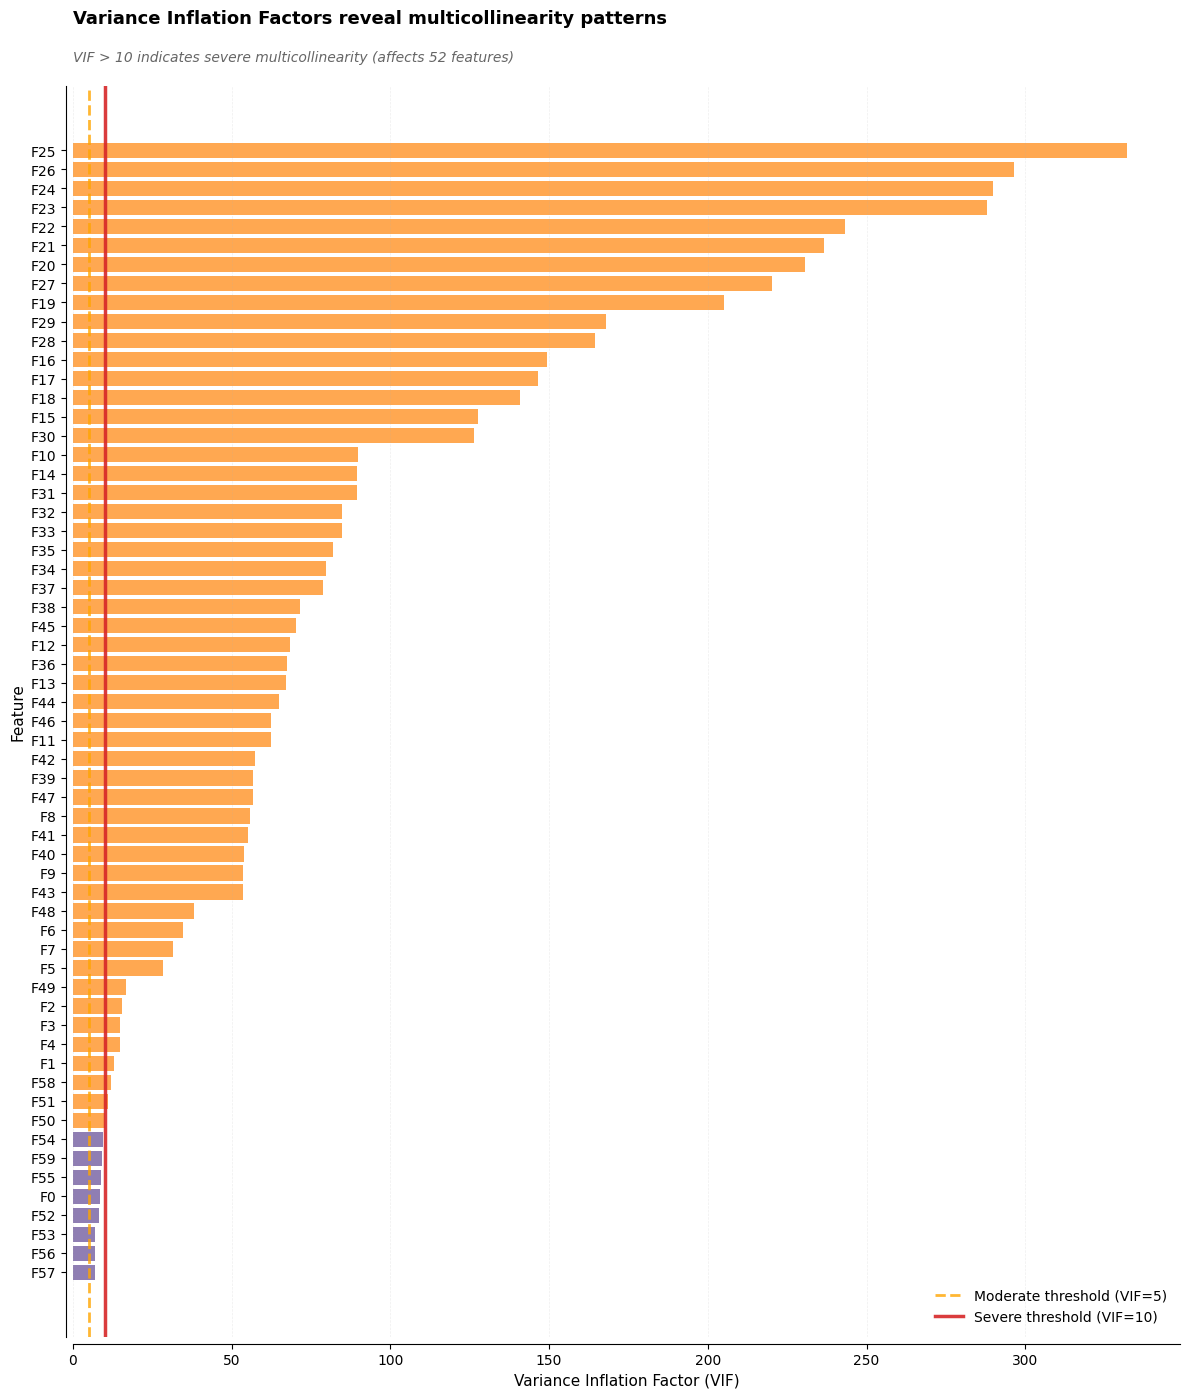

In [ ]:
# Run all correlation analyses
correlations = eda.analyze_correlations()

# VIF analysis - primary multicollinearity diagnostic
correlations['vif'].plot()

# VIF distribution statistics extra telemetry
#correlations['vif'].summary()


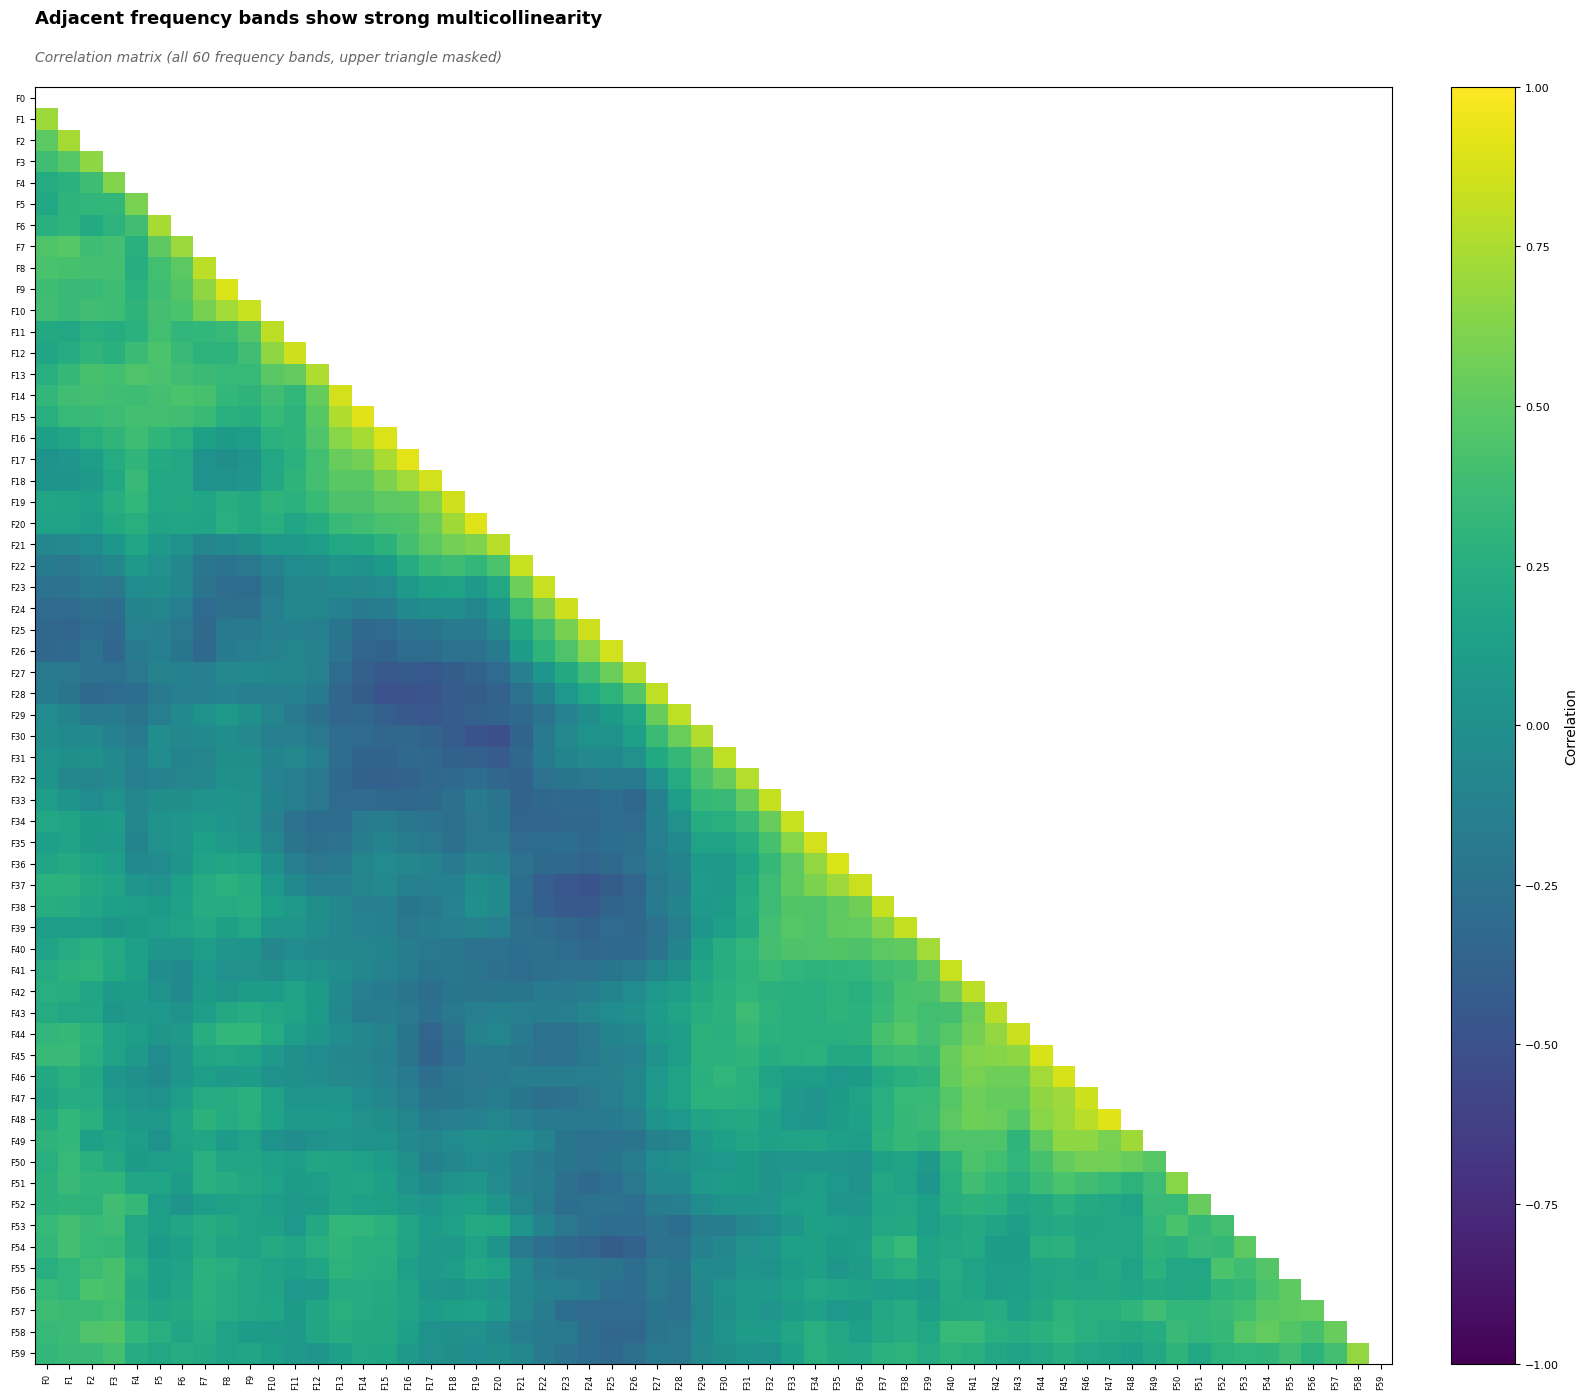

In [12]:
# Correlation matrix heatmap (upper triangle masked)
correlations['multicollinearity'].plot()

In [10]:
# Overall summary more telementary commented out 
#correlations.summarize()

### 3.2 Class-Specific Frequency Signatures

**Hypothesis:** Some frequency bands correlate more strongly with mines, others with rocks, revealing class-specific acoustic signatures across the spectrum.

**Insight:**

Hypothesis confirmed. 48 frequency bands favor mines (positive correlation), 12 favor rocks (negative correlation). High-frequency bands (40-59) show strongest discrimination where metal resonance produces distinct signatures.

**DECISION:** High-frequency bands warrant attention during model training. Feature importance analysis should confirm whether models prioritise these bands.

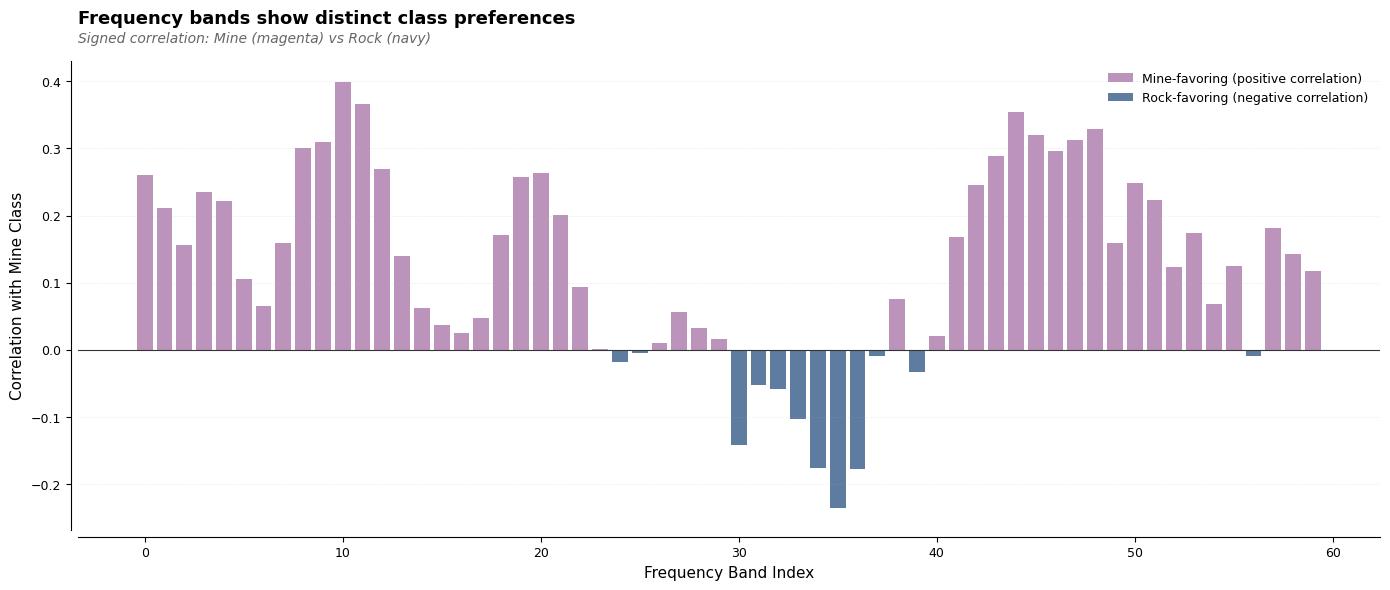


CLASS-SPECIFIC FREQUENCY SIGNATURES
  Mine-favoring frequencies: 48
  Rock-favoring frequencies: 12
  Strongest region: high
  Hypothesis: CONFIRMED

  Implication: High frequency bands show strongest class discrimination



In [13]:
# Class signature analysis
correlations['class_signatures'].plot()
correlations['class_signatures'].summary()

### 3.3 Non-Linear Relationships

**Hypothesis:** Mutual information reveals non-linear discriminative patterns missed by Pearson correlation, suggesting which model families to prioritise.

**Insight:**

Hypothesis rejected. Mutual information aligns tightly with Pearson correlation. Only 19 features show substantial rank divergence. Linear intensity differences dominate. KNN faces challenges (multicollinearity distorts distance metrics). Neural networks appear overengineered for this linear-dominant, small-sample problem.

**DECISION:** Prioritize methods handling multicollinearity naturally (Random Forest, non-linear SVMs) or through regularization (Ridge, Elastic Net). KNN viable only with PCA. Neural networks not recommended.

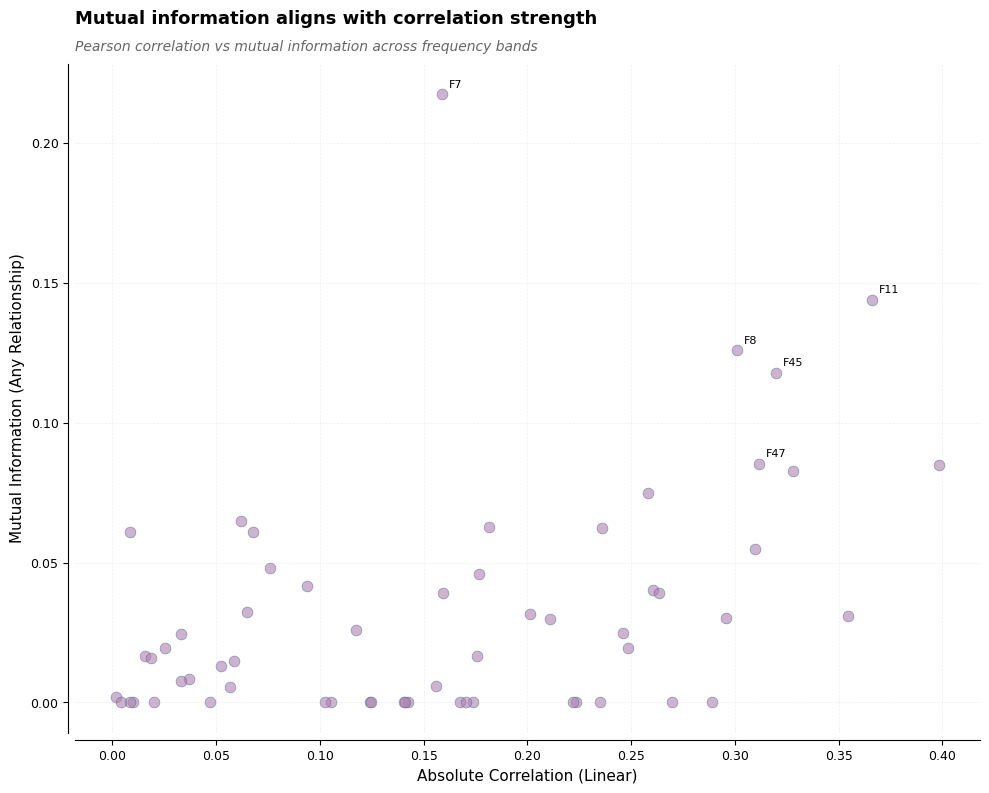


NON-LINEAR RELATIONSHIP ASSESSMENT
  Non-linear candidates: 19
  MI-correlation alignment: weak
  Hypothesis: CONFIRMED

  Implication: Linear relationships dominate. Non-linear models optional but not critical.



In [14]:
# Mutual information analysis
correlations['mutual_information'].plot()
correlations['mutual_information'].summary()

### 3.4 Dimensionality Reduction Potential

**Hypothesis:** With 60 correlated frequency bands, PCA should capture 95% of variance with significantly fewer components.

**Insight:** Hypothesis confirmed. 29 principal components capture 95% of variance (52% reduction). Variance concentrates in first 15 components. KNN benefits substantially from PCA preprocessing (decorrelated components provide reliable distance metrics).

**DECISION:** Maintain two preprocessing pipelines: (1) raw 60-band features for tree-based and regularized linear methods, (2) PCA-transformed 29 components for KNN or if training time proves excessive.

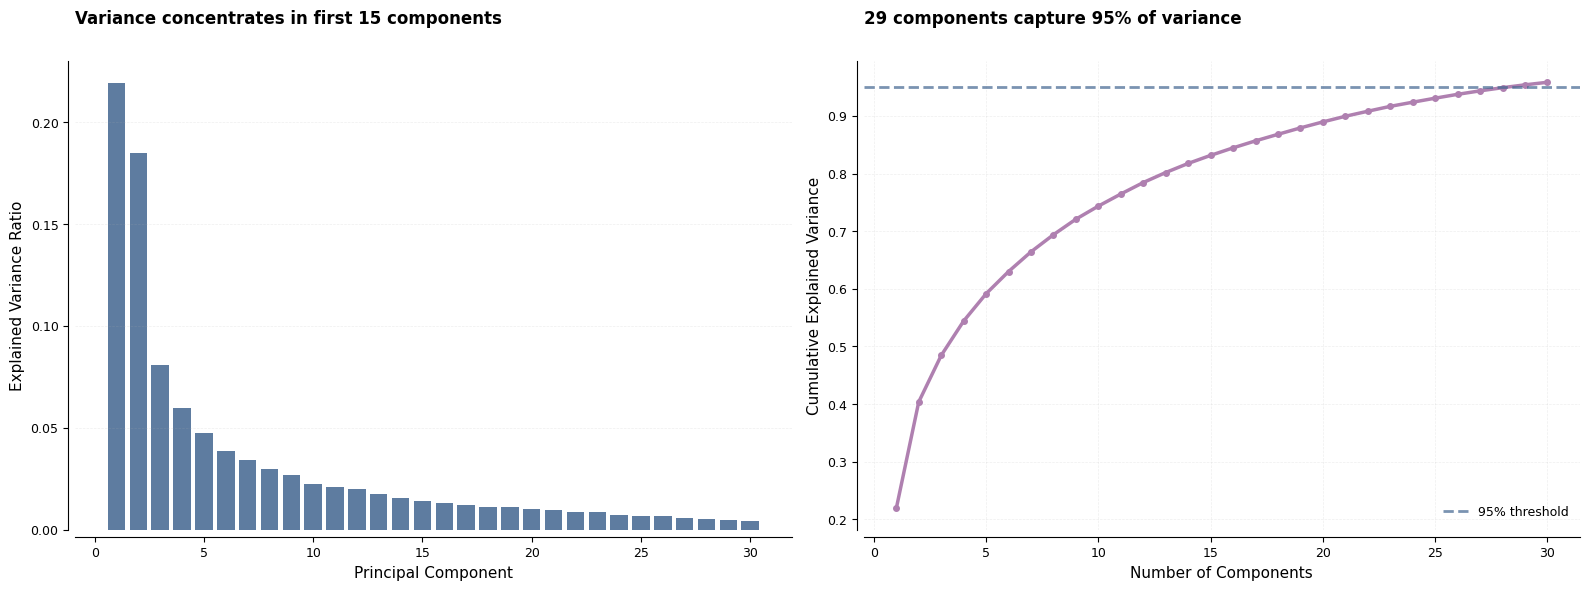


DIMENSIONALITY REDUCTION POTENTIAL
  Original dimensions: 60
  95% variance components: 29
  Reduction potential: 51.7%
  Hypothesis: CONFIRMED

  Implication: PCA optional. Can reduce 60 → 29 if needed.



In [ ]:
# PCA analysis
correlations['pca'].plot()
correlations['pca'].summary()

---

## 4. Class Separability (KDE Patterns)

**Hypothesis:** Individual frequency bands provide sufficient class separation to enable simple threshold-based classification rules.

**Insight:**

Hypothesis rejected. Kernel density estimation across all 60 bands reveals no single feature achieves perfect separation. Mines and rocks share acoustic properties in every individual frequency. The visualizations below show three separation tiers: strong (mean difference > 0.5), moderate (0.3-0.5), and weak (<0.3), but none qualify for spreadsheet-style thresholding.

The varying separation levels indicate different frequencies capture different acoustic aspects: metal resonance, surface texture, geometric reflection. This partial, distributed separation explains why multivariate models outperform univariate rules. Patterns across multiple bands (which frequencies are loud, which quiet, their relative intensities) provide the discriminative signal.

**DECISION:** Classification is feasible but requires multivariate methods (non-linear Support Vector Machines, Random Forest) that learn decision boundaries across the full feature space where class separation emerges from feature combinations, not individual bands.

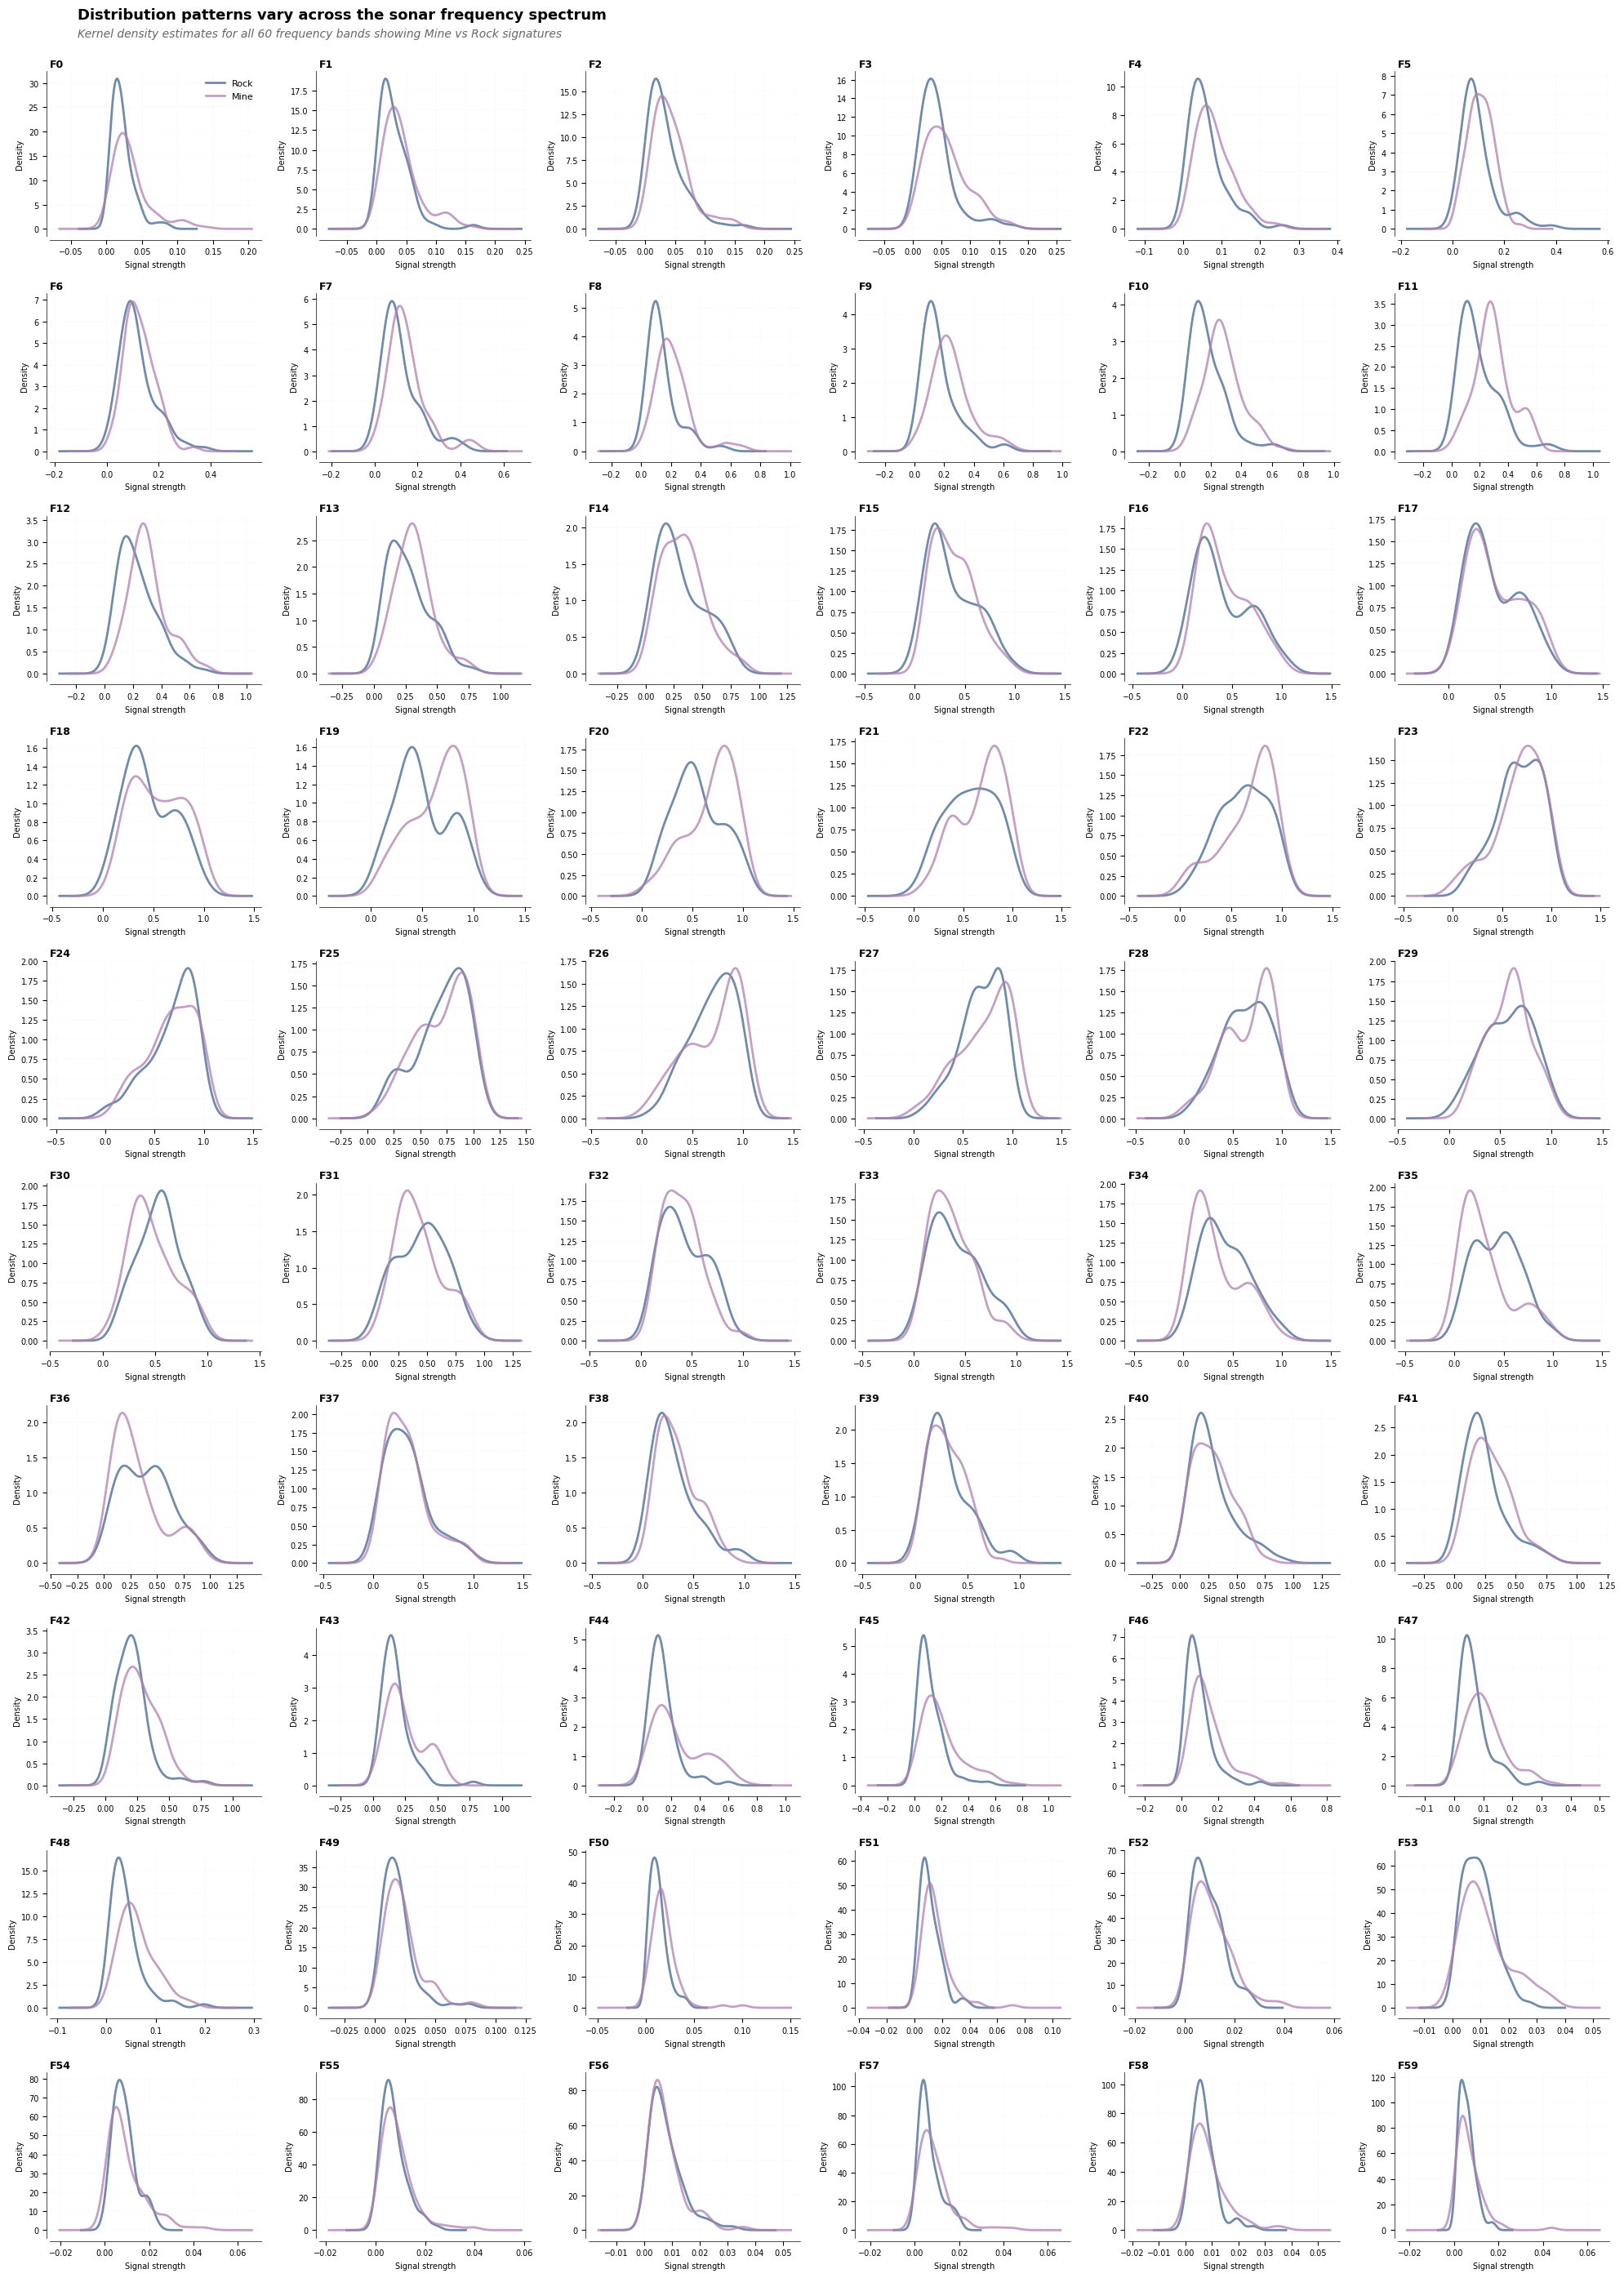


DISTRIBUTIONAL SEPARATION ANALYSIS
  Features with strong separation (>0.5): 16
  Features with moderate separation (0.3-0.5): 15
  Features with weak separation (<0.3): 29

Top 10 most separated features:
   feature  separation
feature_10    0.866278
feature_11    0.781696
feature_44    0.770378
feature_48    0.695367
feature_45    0.682812
feature_47    0.660837
 feature_9    0.651551
 feature_8    0.633269
feature_46    0.624100
feature_43    0.607703


FINDINGS
  strong_sep_count: 16
  moderate_sep_count: 15
  weak_sep_count: 29
  avg_separation: 0.3267455268392853
  top_features: ['feature_10', 'feature_11', 'feature_44', 'feature_48', 'feature_45', 'feature_47', 'feature_9', 'feature_8', 'feature_46', 'feature_43']

IMPLICATIONS
  • 16 features show clear distributional separation
  • 15 features exhibit moderate overlap
  • 29 features heavily overlapping - need feature combinations
  • Average separation: 0.327 (moderate overall)
  • No single feature perfectly separates class

In [ ]:
# Run separability analysis
separability = eda.analyze_separability()

# Generate KDE grid for all 60 features
separability.plot_all()

# Display separation metrics
separability.separation_summary()

# Overall assessment
#separability.summarize()

---

## 5. Preprocessing Requirements

**Hypothesis:** The feature data requires extensive preprocessing (imputation, outlier removal, scaling, feature selection) before model training.

**Insight:**

Hypothesis partially rejected. The frequency data contains 80 outliers (IQR method) across 10 features, representing genuine acoustic edge cases rather than measurement errors. Feature magnitudes range from 0.0001 to 1.0 (range SD = 0.37). All features maintain meaningful signal variability (no near-constant features). Zero missing values means no imputation needed.

Scaling becomes critical only for distance-based and gradient-based algorithms (SVM, KNN, Logistic Regression), where unequal magnitudes create unfair feature weighting. Tree-based models operate on rank order within features, making them scale-invariant.

**DECISION:** Apply StandardScaler before training Support Vector Machines, KNN, and Logistic Regression. Tree-based models (Random Forest) consume raw features directly. Retain all outliers as valid sonar readings. No feature removal or imputation required.

In [17]:
# Run preprocessing analysis
preprocessing = eda.assess_preprocessing()

# Overall summary
#preprocessing.summarize()

### 5.1 Outlier Detection

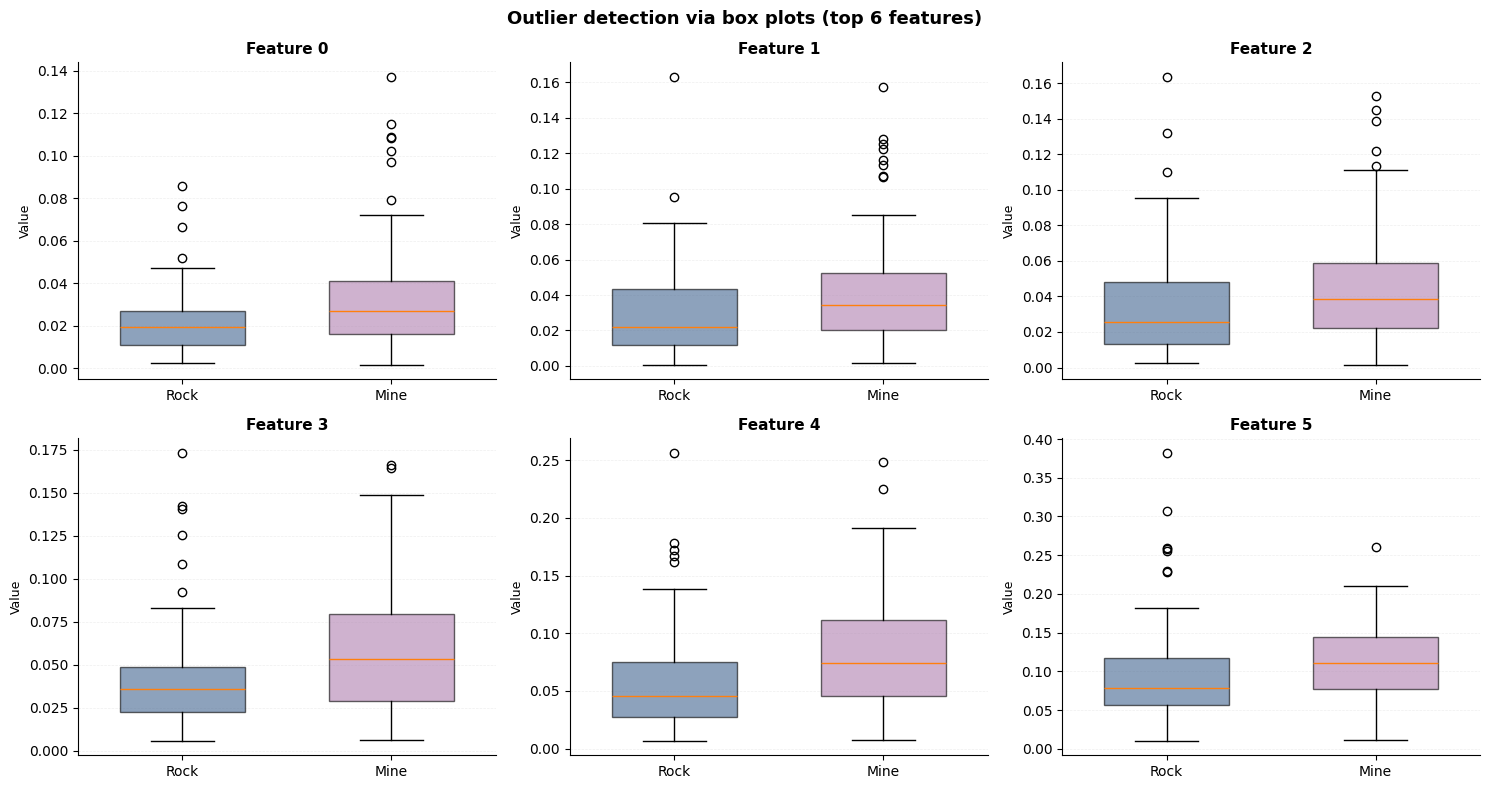


OUTLIER ASSESSMENT
  Total outliers (IQR method): 80
  Total outliers (Z-score >3): 35
  Features with outliers: 10

  Decision: Keep outliers - genuine sonar readings. Use robust scaling if needed.



In [16]:
# Outlier analysis
preprocessing['outliers'].plot()
preprocessing['outliers'].summary()

### 5.2 Scaling Requirements

In [ ]:
# Scaling assessment
preprocessing['scaling'].analyze()


SCALING REQUIREMENTS
  Overall min: 0.0001
  Overall max: 1.0000
  Average range: 0.6154
  Range std dev: 0.3659

  Recommendation: StandardScaler required for distance-based models (SVM, KNN). Not required for tree-based models (Random Forest).



---

## 6. Modeling Strategy

**Hypothesis:** Given the feature structure revealed in Sections 1-5, certain model families will outperform others based on how they handle multicollinearity, class separation patterns, and preprocessing requirements.

**Insight:**

The evidence points toward specific algorithmic strengths. Complete, balanced data (166 samples, 53% rocks) eliminates resampling needs. Severe multicollinearity (87% of features VIF > 10) demands algorithms handling correlated predictors. Linear relationships dominate (MI aligns with Pearson), validating regularized linear methods but requiring Ridge or Elastic Net penalties. No single feature achieves clean separation, necessitating multivariate decision boundaries.

Random Forest emerges as the natural baseline: handles multicollinearity through random feature subsampling, requires no preprocessing, aggregates partial information across many weak learners. Non-linear Support Vector Machines offer curved decision boundaries with explicit high-dimensional mechanisms, requiring StandardScaler preprocessing. Elastic Net Logistic Regression provides interpretable linear baselines with mandatory regularization.

KNN our favourite due to its simplicity, may struggles with multicollinearity distorting distance metrics and would benefit from PCA. 

**DECISION:** Prioritize Random Forest (baseline, no preprocessing), non-linear Support Vector Machines (with StandardScaler), and Elastic Net Logistic Regression (with StandardScaler). Train on both raw 60-feature and PCA-reduced 29-component spaces. Evaluate using F2 score. Reserve threshold optimisation for Notebook 3 after identifying the champion model.

In [30]:
# Generate comprehensive strategy
strategy = eda.generate_modeling_strategy()

# Display full strategy
#print(strategy.summary())

# Prioritised recommendations
#strategy.display_recommendations()

Appendix: Class Signature Visualization (Radar Plot)

Visual representation of mean feature values by class.
Shows the unique "sonar fingerprint" of mines vs rocks.